# PART B: Statistical Models (ARIMA/SARIMA)
=====================================================================

SQUAD 3 - ADMISSION FORECASTING
PART B: Statistical Models (ARIMA/SARIMA)

Structured to match your 5-point task outline exactly.
Each numbered section below = one notebook section/heading.

Requires PART A's handoff file: admissions_timeseries.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
try:
    from sklearn.metrics import root_mean_squared_error
    HAS_RMSE_FN = True
except ImportError:
    HAS_RMSE_FN = False

pd.set_option("display.max_columns", None)

## 1. LOAD PERSON A'S SERIES AND SPLIT

Shape: (3652, 1)
Date range: 1999-01-01 to 2008-12-30
            admissions
Date                  
1999-01-01          34
1999-01-02          30
1999-01-03          24
1999-01-04          28
1999-01-05          31
Train/test split date: 2008-11-18

Train: 1999-01-01 to 2008-11-18 (3610 days)
Test:  2008-11-19 to 2008-12-30 (42 days)


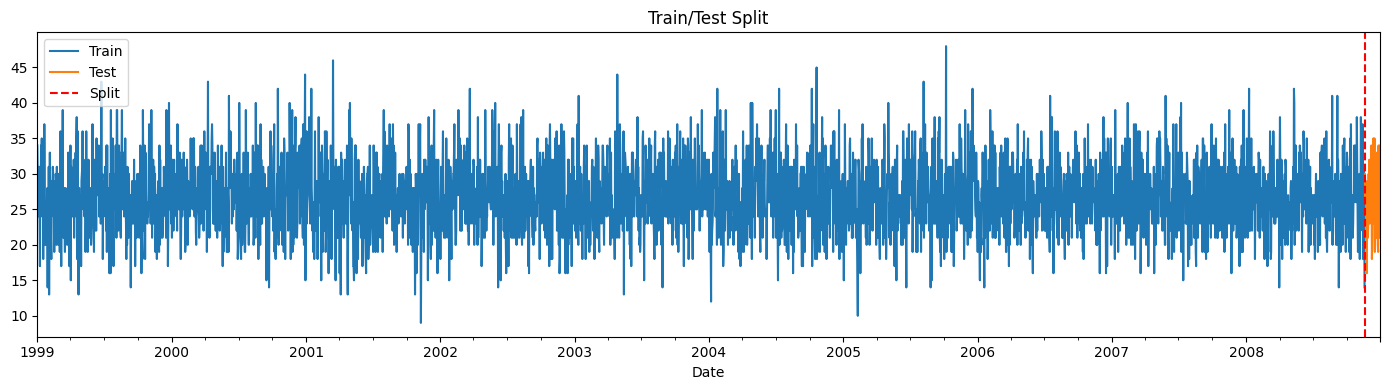

In [2]:
# --- 1a. Load the daily series PART A handed off ---
# NOTE: PART A's notebook saved the file with these exact names -
# index column "Date" and value column "Admissions". We rename the
# value column to "admissions" (lowercase) for consistency below.
daily = pd.read_csv(
    "../data/cleaned/daily_admissions.csv",
    index_col="Date",
    parse_dates=True,
)
daily = daily.rename(columns={"Admissions": "admissions"})
daily = daily.asfreq("D")
print("Shape:", daily.shape)
print("Date range:", daily.index.min().date(), "to", daily.index.max().date())
print(daily.head())

# --- 1b. Compute the split date (Person A's notebook didn't output one
# explicitly, so we calculate it the same way: last 6 weeks as test) ---
TRAIN_TEST_SPLIT_DATE = (daily.index.max() - pd.Timedelta(weeks=6)).strftime("%Y-%m-%d")
print(f"Train/test split date: {TRAIN_TEST_SPLIT_DATE}")
# Confirm with Person A and Person C that this matches what they're using
# before proceeding, so everyone evaluates on the identical holdout period.

train = daily.loc[:TRAIN_TEST_SPLIT_DATE, "admissions"]
test = daily.loc[TRAIN_TEST_SPLIT_DATE:, "admissions"]
# Avoid double-counting the split date itself in both sets:
test = test.iloc[1:]

print(f"\nTrain: {train.index.min().date()} to {train.index.max().date()} ({len(train)} days)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)")

fig, ax = plt.subplots(figsize=(14, 4))
train.plot(ax=ax, label="Train")
test.plot(ax=ax, label="Test")
ax.axvline(pd.Timestamp(TRAIN_TEST_SPLIT_DATE), color="red", linestyle="--", label="Split")
ax.legend()
ax.set_title("Train/Test Split")
plt.tight_layout()
plt.savefig("../models/admission_forecasting/train_test_split.png", dpi=150)
plt.show()

## 2. DETERMINE MODEL ORDER

In [3]:
# --- 2a. PART A's manual read (from her notebook's Summary section) ---
# Her ADF test: statistic=-36.83, p-value=0.0 -> stationary
# Her KPSS test: statistic=0.0531, p-value=0.1 -> stationary
# Both tests agree the raw series is already stationary, so d=0 (no
# differencing needed) - this is DIFFERENT from a typical non-stationary
# hospital series, so don't assume d=1 by default here.
persons_a_suggested_order = (1, 0, 1)              # (p, d, q) from A's notes
persons_a_suggested_seasonal_order = (1, 0, 1, 7)   # (P, D, Q, m) from A's notes
print("Persons A's suggested starting order:", persons_a_suggested_order,
      persons_a_suggested_seasonal_order)

# --- 2b. Let auto_arima search automatically ---
auto_model = auto_arima(
    train,
    seasonal=True,
    m=7,                 # weekly seasonality on daily data
    trace=True,           # prints the search process - useful to include in your report
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
)
print(auto_model.summary())

auto_order = auto_model.order
auto_seasonal_order = auto_model.seasonal_order
print(f"\nauto_arima chose order={auto_order}, seasonal_order={auto_seasonal_order}")

# --- 2c. Compare against A's manual read ---
print(f"\nPerson A suggested: {persons_a_suggested_order} x {persons_a_suggested_seasonal_order}")
print(f"auto_arima chose:   {auto_order} x {auto_seasonal_order}")
# If these disagree substantially (e.g. very different p/q, or very
# different seasonal terms), flag it to A rather than silently picking
# one - could mean the ACF/PACF was misread, or auto_arima's stepwise
# search settled on a local optimum. Try both and compare AIC/BIC and
# test-set performance if unsure.

FINAL_ORDER = auto_order              # or persons_a_suggested_order if you prefer that
FINAL_SEASONAL_ORDER = auto_seasonal_order
FINAL_TREND = "c" if auto_model.with_intercept else None
print(f"\nauto_arima included an intercept: {auto_model.with_intercept}")
print(f"-> will use trend={FINAL_TREND!r} when refitting with statsmodels SARIMAX")

# --- 2d. Quick diagnostic: does the series have much real structure? ---
# If auto_arima settles on (0,0,0)(0,0,0,m) with no AR/MA/seasonal terms,
# that's a sign the series may behave close to white noise around a
# constant mean - i.e. little genuine day-to-day pattern to forecast.
# Worth checking and reporting, not just proceeding blindly.
cv = daily["admissions"].std() / daily["admissions"].mean()
print(f"\nMean admissions: {daily['admissions'].mean():.2f}")
print(f"Std admissions:  {daily['admissions'].std():.2f}")
print(f"Coefficient of variation: {cv:.3f}")
if FINAL_ORDER == (0, 0, 0) and FINAL_SEASONAL_ORDER[:3] == (0, 0, 0):
    print("\nNOTE: auto_arima found no AR/MA/seasonal structure at all.")
    print("This suggests the series may be close to random noise around a")
    print("constant mean. Worth flagging to the team as a data limitation")
    print("(e.g. if admission_date was synthetically assigned close to")
    print("randomly, there may be little real temporal pattern to model).")

# =====================================================================
# 2e. DEEPER STRUCTURE CHECK (optional but recommended)
# =====================================================================
# Before concluding "no structure exists", rule out two things:
#   (i)  auto_arima's stepwise search bailing out due to numerical
#        convergence failures (AIC=inf) rather than genuinely worse fit
#   (ii) a weak/greedy search missing a better model entirely
# Then directly test the weekday-effect claim statistically.

# --- (i) Try PART A's manually-suggested order with a different optimizer ---
# AIC=inf on complex candidates during the auto_arima search usually means
# the default optimizer failed to converge, not that the model is bad.
manual_model = SARIMAX(
    train,
    order=persons_a_suggested_order,             # (1, 0, 1)
    seasonal_order=persons_a_suggested_seasonal_order,  # (1, 0, 1, 7)
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
)
manual_fitted = manual_model.fit(disp=False, method="powell")
manual_forecast = manual_fitted.get_forecast(steps=len(test)).predicted_mean
manual_forecast.index = test.index

mae_manual = mean_absolute_error(test, manual_forecast)
rmse_manual = (root_mean_squared_error(test, manual_forecast) if HAS_RMSE_FN
               else mean_squared_error(test, manual_forecast, squared=False))
print(f"\nManual order {persons_a_suggested_order}x{persons_a_suggested_seasonal_order}: "
      f"MAE={mae_manual:.2f}, RMSE={rmse_manual:.2f} (AIC={manual_fitted.aic:.2f})")
print(f"Compare to auto_arima {FINAL_ORDER}x{FINAL_SEASONAL_ORDER}: "
      f"AIC={auto_model.aic():.2f} (test-set MAE/RMSE computed in Section 3)")

# --- (ii) Full (non-stepwise) grid search - slower but more thorough ---
auto_model_thorough = auto_arima(
    train,
    seasonal=True,
    m=7,
    stepwise=False,        # full grid search instead of greedy stepwise
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    n_jobs=-1,
)
print("\n--- Thorough (non-stepwise) search result ---")
print(auto_model_thorough.summary())
print(f"Thorough search chose: order={auto_model_thorough.order}, "
      f"seasonal_order={auto_model_thorough.seasonal_order}, "
      f"AIC={auto_model_thorough.aic():.2f}")
print(f"(compare to stepwise search AIC={auto_model.aic():.2f} - lower AIC is better)")

# --- (iii) Direct statistical test: does weekday actually matter? ---
daily["weekday"] = daily.index.day_name()
weekday_stats = daily.groupby("weekday")["admissions"].agg(["mean", "std"])
print("\nAdmissions by weekday:\n", weekday_stats)

from scipy.stats import f_oneway
weekday_groups = [daily[daily["weekday"] == day]["admissions"].values
                   for day in daily["weekday"].unique()]
f_stat, anova_p = f_oneway(*weekday_groups)
print(f"\nANOVA across weekdays: F={f_stat:.3f}, p={anova_p:.4f}")
if anova_p > 0.05:
    print("-> No statistically significant weekday effect found (p > 0.05).")
    print("   This supports reporting 'no meaningful weekly seasonality'")
    print("   as a genuine data characteristic, not a modeling shortfall.")
else:
    print("-> A statistically significant weekday effect DOES exist (p <= 0.05).")
    print("   If auto_arima still isn't capturing it, that points back to a")
    print("   search/convergence issue worth revisiting with a manual order.")

Persons A's suggested starting order: (1, 0, 1) (1, 0, 1, 7)
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=inf, Time=7.53 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=22057.185, Time=0.05 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=22059.638, Time=1.65 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=22059.256, Time=0.73 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=34131.958, Time=0.03 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AIC=22057.826, Time=1.51 sec
 ARIMA(0,0,0)(0,0,1)[7] intercept   : AIC=22057.762, Time=0.30 sec
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AIC=inf, Time=4.57 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=22058.702, Time=0.32 sec
 ARIMA(0,0,1)(0,0,0)[7] intercept   : AIC=22058.700, Time=0.16 sec
 ARIMA(1,0,1)(0,0,0)[7] intercept   : AIC=22060.699, Time=0.36 sec

Best model:  ARIMA(0,0,0)(0,0,0)[7] intercept
Total fit time: 17.242 seconds
                               SARIMAX Results                                
Dep. Variable:

## 3. FIT AND VALIDATE

                               SARIMAX Results                                
Dep. Variable:             admissions   No. Observations:                 3610
Model:                        SARIMAX   Log Likelihood              -11023.067
Date:                Thu, 23 Jul 2026   AIC                          22050.134
Time:                        14:26:59   BIC                          22062.517
Sample:                    01-01-1999   HQIC                         22054.547
                         - 11-18-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     26.8479      0.086    311.766      0.000      26.679      27.017
sigma2        26.3319      0.610     43.139      0.000      25.135      27.528
Ljung-Box (L1) (Q):                   0.50   Jarque-

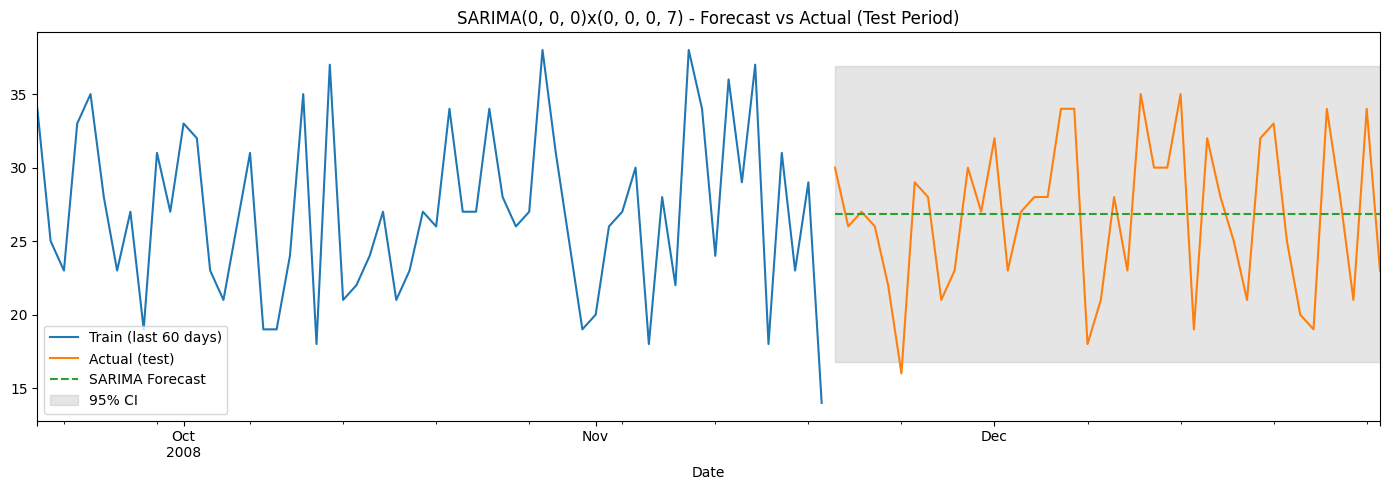


Mean residual (actual - forecast): -0.06
Positive mean residual = model is under-forecasting on average.
Negative mean residual = model is over-forecasting on average.


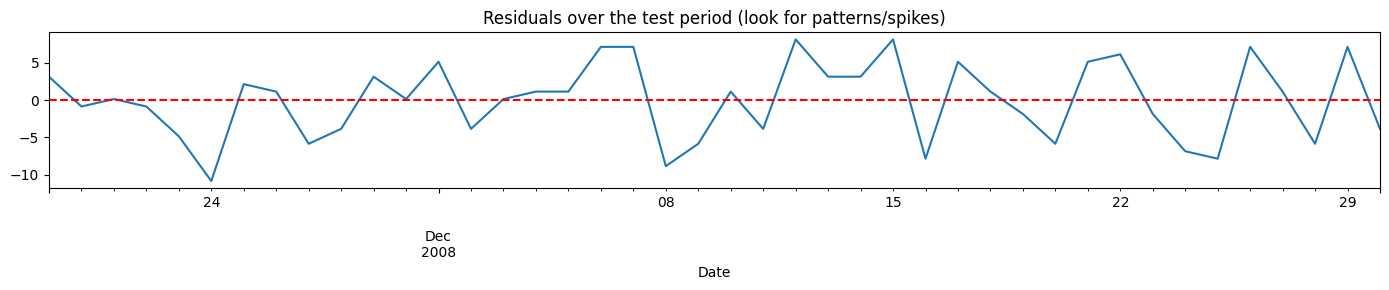


Test-period performance:
MAE:  4.28
RMSE: 5.12
MAPE: 17.36%


In [4]:
# --- 3a. Fit SARIMA on the training set ---
model = SARIMAX(
    train,
    order=FINAL_ORDER,
    seasonal_order=FINAL_SEASONAL_ORDER,
    trend=FINAL_TREND,   # preserves the intercept auto_arima found - without
                          # this, a (0,0,0) model collapses to forecasting 0
    enforce_stationarity=False,
    enforce_invertibility=False,
)
fitted = model.fit(disp=False)
print(fitted.summary())

# --- 3b. Forecast across the test period ---
n_test = len(test)
forecast_result = fitted.get_forecast(steps=n_test)
test_forecast = forecast_result.predicted_mean
test_forecast.index = test.index
conf_int = forecast_result.conf_int(alpha=0.05)
conf_int.index = test.index

# --- 3c. Plot forecast vs actual ---
fig, ax = plt.subplots(figsize=(14, 5))
train[-60:].plot(ax=ax, label="Train (last 60 days)")
test.plot(ax=ax, label="Actual (test)")
test_forecast.plot(ax=ax, label="SARIMA Forecast", linestyle="--")
ax.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                 color="gray", alpha=0.2, label="95% CI")
ax.legend()
ax.set_title(f"SARIMA{FINAL_ORDER}x{FINAL_SEASONAL_ORDER} - Forecast vs Actual (Test Period)")
plt.tight_layout()
plt.savefig("../models/admission_forecasting/sarima_test_forecast.png", dpi=150)
plt.show()

# --- 3d. Check for systematic over/under-shooting ---
residuals = test - test_forecast
print(f"\nMean residual (actual - forecast): {residuals.mean():.2f}")
print("Positive mean residual = model is under-forecasting on average.")
print("Negative mean residual = model is over-forecasting on average.")

fig, ax = plt.subplots(figsize=(14, 3))
residuals.plot(ax=ax)
ax.axhline(0, color="red", linestyle="--")
ax.set_title("Residuals over the test period (look for patterns/spikes)")
plt.tight_layout()
plt.savefig("../models/admission_forecasting/sarima_residuals.png", dpi=150)
plt.show()

# --- 3e. Test-period accuracy metrics ---
mae_test = mean_absolute_error(test, test_forecast)
if HAS_RMSE_FN:
    rmse_test = root_mean_squared_error(test, test_forecast)
else:
    rmse_test = mean_squared_error(test, test_forecast, squared=False)
mape_test = (np.abs((test - test_forecast) / test.replace(0, np.nan))).mean() * 100

print(f"\nTest-period performance:")
print(f"MAE:  {mae_test:.2f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"MAPE: {mape_test:.2f}%")

## 4. PRODUCE FINAL FORECASTS


Future daily forecast (first 10 rows):
            arima_forecast   lower_ci   upper_ci
date                                            
2008-12-31       26.847147  16.789922  36.904372
2009-01-01       26.847147  16.789922  36.904372
2009-01-02       26.847147  16.789922  36.904372
2009-01-03       26.847147  16.789922  36.904372
2009-01-04       26.847147  16.789922  36.904372
2009-01-05       26.847147  16.789922  36.904372
2009-01-06       26.847147  16.789922  36.904372
2009-01-07       26.847147  16.789922  36.904372
2009-01-08       26.847147  16.789922  36.904372
2009-01-09       26.847147  16.789922  36.904372


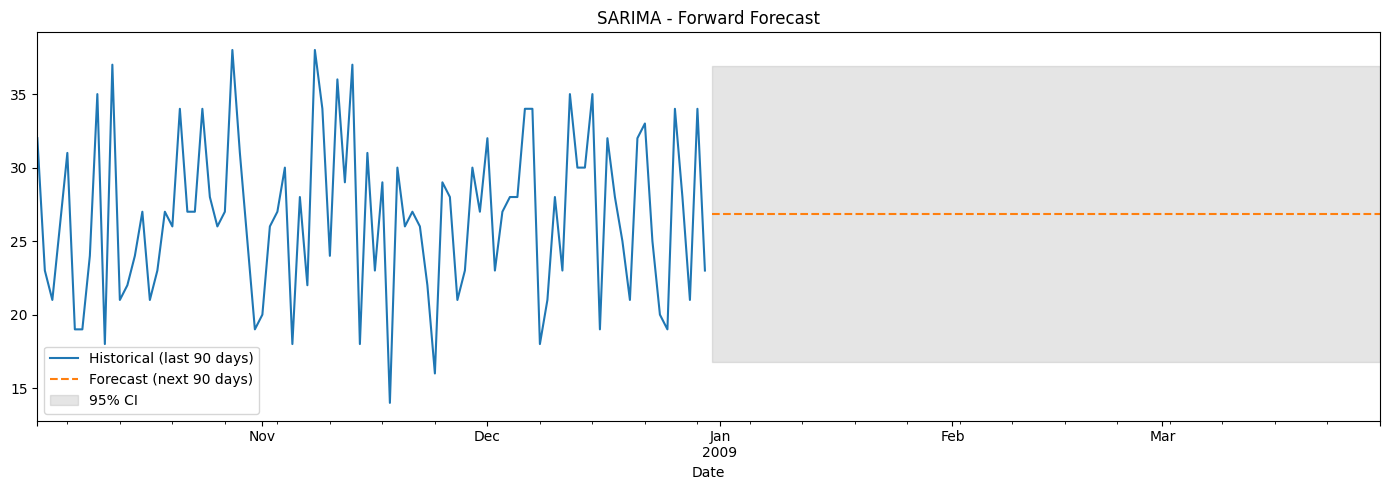


Weekly forecast:
             arima_forecast
date                      
2009-01-04      134.235735
2009-01-11      187.930029
2009-01-18      187.930029
2009-01-25      187.930029
2009-02-01      187.930029

Monthly forecast:
             arima_forecast
date                      
2008-12-31       26.847147
2009-01-31      832.261556
2009-02-28      751.720115
2009-03-31      805.414409


In [5]:
# --- 4a. Refit on the FULL series (train + test) ---
full_series = daily["admissions"]
final_model = SARIMAX(
    full_series,
    order=FINAL_ORDER,
    seasonal_order=FINAL_SEASONAL_ORDER,
    trend=FINAL_TREND,   # same fix as Section 3 - keep the intercept
    enforce_stationarity=False,
    enforce_invertibility=False,
)
final_fitted = final_model.fit(disp=False)

# --- 4b. Forecast forward ---
FORECAST_HORIZON_DAYS = 90  # adjust to whatever the project needs (e.g. 30/60/90)
future_forecast_result = final_fitted.get_forecast(steps=FORECAST_HORIZON_DAYS)
future_dates = pd.date_range(
    start=full_series.index.max() + pd.Timedelta(days=1),
    periods=FORECAST_HORIZON_DAYS,
    freq="D",
)
future_forecast = future_forecast_result.predicted_mean
future_forecast.index = future_dates
future_conf_int = future_forecast_result.conf_int(alpha=0.05)
future_conf_int.index = future_dates

arima_daily_forecast = pd.DataFrame({
    "date": future_dates,
    "arima_forecast": future_forecast.values,
    "lower_ci": future_conf_int.iloc[:, 0].values,
    "upper_ci": future_conf_int.iloc[:, 1].values,
}).set_index("date")

print("\nFuture daily forecast (first 10 rows):")
print(arima_daily_forecast.head(10))

fig, ax = plt.subplots(figsize=(14, 5))
full_series[-90:].plot(ax=ax, label="Historical (last 90 days)")
future_forecast.plot(ax=ax, label=f"Forecast (next {FORECAST_HORIZON_DAYS} days)", linestyle="--")
ax.fill_between(future_conf_int.index, future_conf_int.iloc[:, 0], future_conf_int.iloc[:, 1],
                 color="gray", alpha=0.2, label="95% CI")
ax.legend()
ax.set_title("SARIMA - Forward Forecast")
plt.tight_layout()
plt.savefig("../models/admission_forecasting/sarima_future_forecast.png", dpi=150)
plt.show()

# --- 4c. Aggregate into weekly/monthly views ---
arima_weekly_forecast = arima_daily_forecast["arima_forecast"].resample("W").sum().to_frame()
arima_monthly_forecast = arima_daily_forecast["arima_forecast"].resample("ME").sum().to_frame()

print("\nWeekly forecast:\n", arima_weekly_forecast.head())
print("\nMonthly forecast:\n", arima_monthly_forecast.head())

## 5. SAVE OUTPUTS

In [6]:
# --- 5a. Save the fitted model ---
with open("../models/admission_forecasting/arima_model.pkl", "wb") as f:
    pickle.dump(final_fitted, f)
print("\nSaved arima_model.pkl")

# --- 5b. Save forecast CSV with actual + forecast + CI ---
# Combine test-period actual-vs-forecast with the pure future forecast
test_comparison = pd.DataFrame({
    "date": test.index,
    "actual": test.values,
    "arima_forecast": test_forecast.values,
    "lower_ci": conf_int.iloc[:, 0].values,
    "upper_ci": conf_int.iloc[:, 1].values,
}).set_index("date")

future_only = arima_daily_forecast.copy()
future_only["actual"] = np.nan
future_only = future_only[["actual", "arima_forecast", "lower_ci", "upper_ci"]]

arima_forecast_full = pd.concat([test_comparison, future_only])
arima_forecast_full.to_csv("../models/admission_forecasting/arima_forecast.csv")
print("Saved arima_forecast.csv")

arima_weekly_forecast.to_csv("../models/admission_forecasting/arima_weekly_forecast.csv")
arima_monthly_forecast.to_csv("../models/admission_forecasting/arima_monthly_forecast.csv")
print("Saved arima_weekly_forecast.csv and arima_monthly_forecast.csv")

# --- 5c. Keep test-period metrics to hand to Person C ---
arima_metrics = pd.DataFrame([{
    "model": "ARIMA/SARIMA",
    "order": str(FINAL_ORDER),
    "seasonal_order": str(FINAL_SEASONAL_ORDER),
    "MAE": mae_test,
    "RMSE": rmse_test,
    "MAPE": mape_test,
}])
arima_metrics.to_csv("../models/admission_forecasting/arima_metrics.csv", index=False)
print("\nSaved arima_metrics.csv - hand this to Person C for the combined evaluation.csv")
print(arima_metrics)

print("\n=== PART B PIPELINE COMPLETE ===")
print("Files ready for handoff: arima_model.pkl, arima_forecast.csv,")
print("arima_weekly_forecast.csv, arima_monthly_forecast.csv, arima_metrics.csv")


Saved arima_model.pkl
Saved arima_forecast.csv
Saved arima_weekly_forecast.csv and arima_monthly_forecast.csv

Saved arima_metrics.csv - hand this to Person C for the combined evaluation.csv
          model      order seasonal_order       MAE      RMSE      MAPE
0  ARIMA/SARIMA  (0, 0, 0)   (0, 0, 0, 7)  4.283639  5.120532  17.35594

=== PART B PIPELINE COMPLETE ===
Files ready for handoff: arima_model.pkl, arima_forecast.csv,
arima_weekly_forecast.csv, arima_monthly_forecast.csv, arima_metrics.csv
